In [1]:
import tensorflow
import keras

In [10]:
from sklearn.datasets import make_circles

In [2]:
from keras.layers import Dense
from keras import Sequential

In [11]:
import pandas
import numpy

In [34]:
X,y = make_circles(n_samples=80,noise=0.1,random_state=5)

In [35]:
X

array([[ 0.6568292 , -0.15134439],
       [-0.80180673, -0.76860993],
       [ 0.0269375 ,  1.01489748],
       [-0.86314553,  0.30257575],
       [-0.85537046, -0.33000394],
       [ 0.59395698,  0.53681153],
       [-0.11496438, -0.88809713],
       [-0.8295319 , -0.61099601],
       [-0.86554113,  0.44387623],
       [ 0.28288481,  0.73588147],
       [-0.33275246,  0.73174972],
       [ 0.81875326, -0.3164814 ],
       [ 0.49103767, -0.60048334],
       [ 0.59276433, -0.9895502 ],
       [-0.48012489,  1.03288961],
       [-0.36207751, -0.66381726],
       [ 0.05810128,  0.7880637 ],
       [ 0.55152553, -0.7277932 ],
       [ 0.13591304, -0.73013433],
       [ 0.59106854,  0.82682115],
       [-0.91179121,  0.25061772],
       [-0.44569029, -0.77168137],
       [-0.52188975, -0.58132904],
       [ 0.63999329, -0.6681362 ],
       [-0.96120179, -0.25142503],
       [ 0.64886289, -0.9599029 ],
       [-0.063975  ,  0.60514567],
       [ 0.57714129,  0.48737394],
       [ 0.34782322,

In [36]:
y

array([1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1])

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=30)

In [4]:
import matplotlib.pyplot as plt

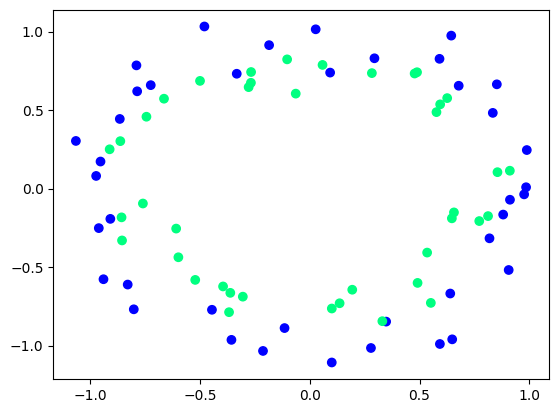

In [50]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter")

In [51]:
model = Sequential()

In [52]:
model.add(Dense(256,activation="relu",input_dim = X.shape[1]))
model.add(Dense(1,activation="sigmoid"))

In [53]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [58]:
history = model.fit(X_train,y_train,validation_data=[X_test,y_test],verbose=0,epochs=2000)

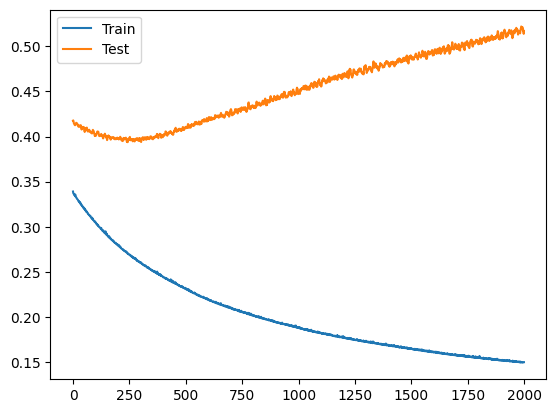

In [59]:
plt.plot(history.history['loss'],label="Train")
plt.plot(history.history['val_loss'],label="Test")
plt.legend()
plt.show()

In [5]:
from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

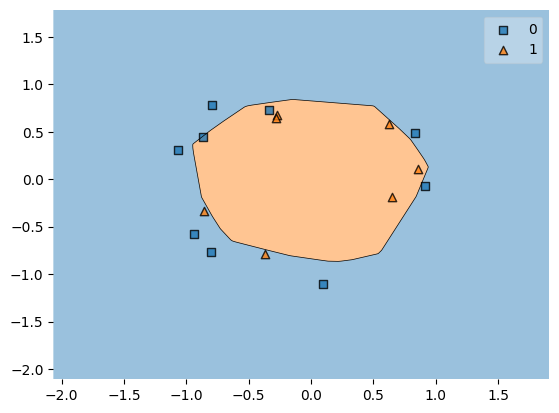

In [61]:
plot_decision_regions(X_test,y_test.ravel(),model)

# implementation early stopping

In [27]:
from keras.callbacks import EarlyStopping

In [39]:
model = Sequential()

In [40]:
model.add(Dense(256,activation="relu",input_dim = X.shape[1]))
model.add(Dense(1,activation="sigmoid"))

In [41]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [46]:
callback = EarlyStopping(
    monitor = "val_loss", 
    min_delta = 0.000001,
    patience=20,
    mode = "auto",
    verbose=1,
    baseline = None, 
    restore_best_weights = False
)

In [47]:
hist = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=2000,callbacks= callback)

Epoch 1/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.5521 - loss: 0.6856 - val_accuracy: 0.4375 - val_loss: 0.7099
Epoch 2/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5938 - loss: 0.6757 - val_accuracy: 0.4375 - val_loss: 0.7100
Epoch 3/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5729 - loss: 0.6805 - val_accuracy: 0.4375 - val_loss: 0.7105
Epoch 4/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5417 - loss: 0.6829 - val_accuracy: 0.4375 - val_loss: 0.7104
Epoch 5/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5729 - loss: 0.6795 - val_accuracy: 0.4375 - val_loss: 0.7102
Epoch 6/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6042 - loss: 0.6699 - val_accuracy: 0.4375 - val_loss: 0.7103
Epoch 7/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5417 - loss: 0.6832 - val_accuracy: 0.4375 - val_loss: 0.7095
Epoch 8/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5625 - loss: 0.6796 - val_accuracy: 0.437

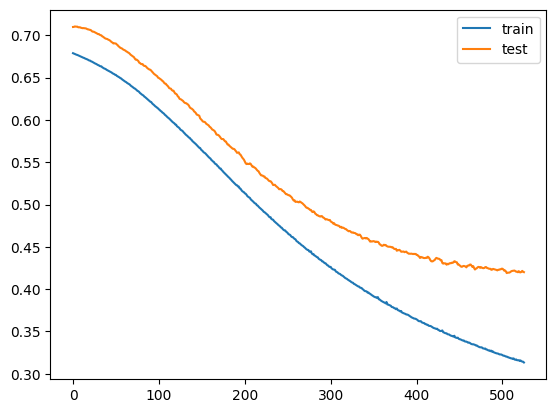

In [48]:
plt.plot(hist.history['loss'],label="train")
plt.plot(hist.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 751us/step


<Axes: >

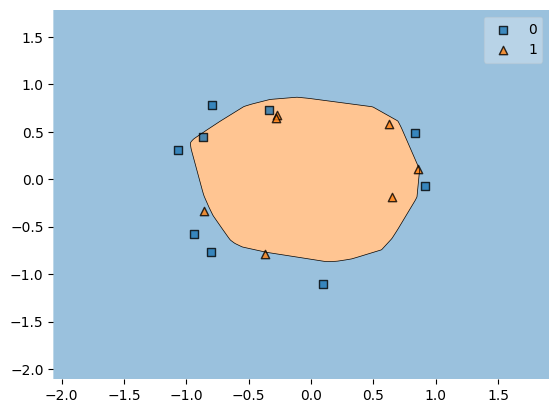

In [49]:
plot_decision_regions(X_test,y_test.ravel(),model)